In [4]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataevaluator import DataEvaluator
from helper import evaluate_model, train_model
from scikeras.wrappers import KerasClassifier

from models.knn import KNN
from models.mlp import MLP
from models.logistic import LogReg
from models.cnn import CNN
from models.random_forest import RandomForest

In [6]:
data = DataEvaluator('dataset')
X_train, y_train, X_val, y_val, X_test, y_test = data.get_data()
print(X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape)
clothing_types = data.clothing_types

(51000, 784) (51000,) (9000, 784) (9000,) (10000, 784) (10000,)


In [7]:
# CNN data preprocessing

X_train_cnn = X_train.reshape((-1, 28, 28, 1)).astype("float32") / 255.0
X_val_cnn   = X_val.reshape((-1, 28, 28, 1)).astype("float32") / 255.0
X_test_cnn  = X_test.reshape((-1, 28, 28, 1)).astype("float32") / 255.0

print(X_train_cnn.shape)
print(X_val_cnn.shape)
print(X_test_cnn.shape)

(51000, 28, 28, 1)
(9000, 28, 28, 1)
(10000, 28, 28, 1)


## Data Exploration

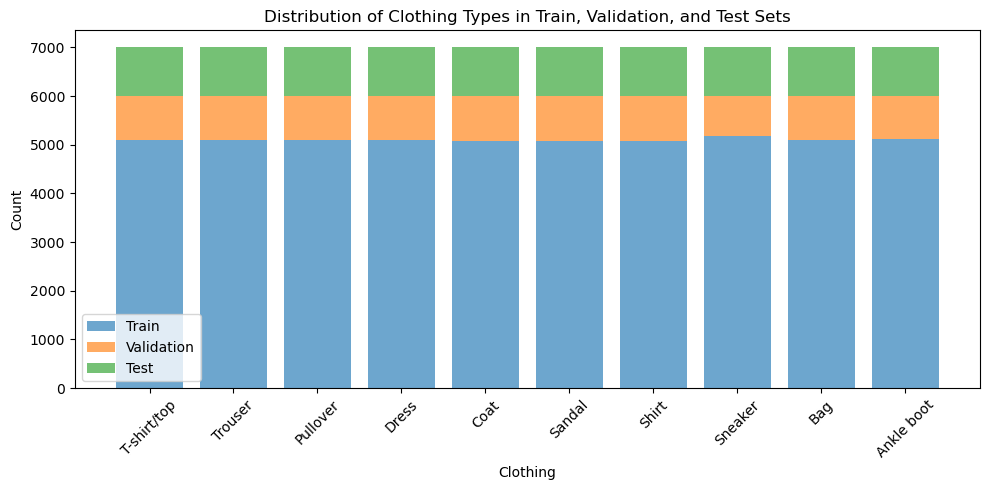

In [8]:
data.plot_clothing_distribution()
print()

# Model Initialization Logic Here

In [9]:
l = LogReg()
k = KNN()
f = MLP()
c = CNN()
r = RandomForest()

# Training Models

In [10]:
ltime, _ = train_model(l, "Logistic Regression", X_train, y_train)
print(f"Training time for Logistic Regression: {ltime:.2f} seconds")

Training time for Logistic Regression: 101.06 seconds


c:\Users\shubh\.conda\envs\cs178thing\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
kfit_time, _ = train_model(k, "kNN", X_train, y_train)
print(f"Training time for kNN: {kfit_time:.2f} seconds")

Training time for kNN: 0.08 seconds


In [12]:
ftime, _ = train_model(f, "MLP", X_train, y_train)
print(f"Training time for MLP: {ftime:.2f} seconds")

Training time for MLP: 89.56 seconds


Training time for Random Forest: 12.77 seconds


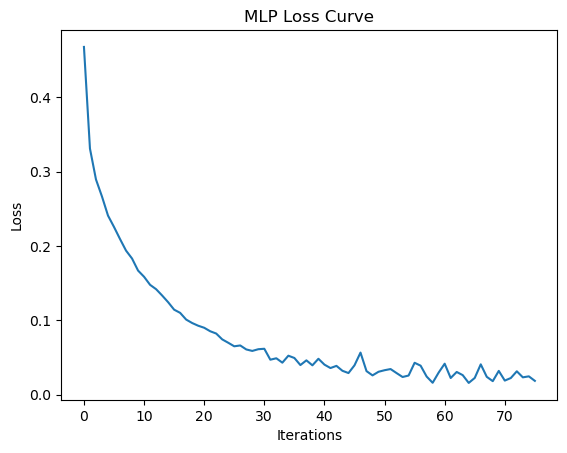

In [13]:
rtime, _ = train_model(r, "Random Forest", X_train, y_train)
print(f"Training time for Random Forest: {rtime:.2f} seconds")

plt.plot(f.classifier.loss_curve_)
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('MLP Loss Curve')
plt.savefig('figures/MLP_loss_curve.png')
plt.show()

c:\Users\shubh\.conda\envs\cs178thing\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.6047 - loss: 1.0764
Epoch 2/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7389 - loss: 0.6956
Epoch 3/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.7697 - loss: 0.6140
Epoch 4/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7881 - loss: 0.5657
Epoch 5/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8016 - loss: 0.5321
Epoch 6/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8125 - loss: 0.5063
Epoch 7/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8209 - loss: 0.4855
Epoch 8/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8292 - loss: 0.4674
Epoch 9/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8350 - loss: 0.4518
Epoch 10/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8390 - loss: 0.4373
Epoch 11/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8445 - loss: 0.4239
Epoch 12/30
399/399 ━━━━━━━━━━━━━━━━━━━━ 

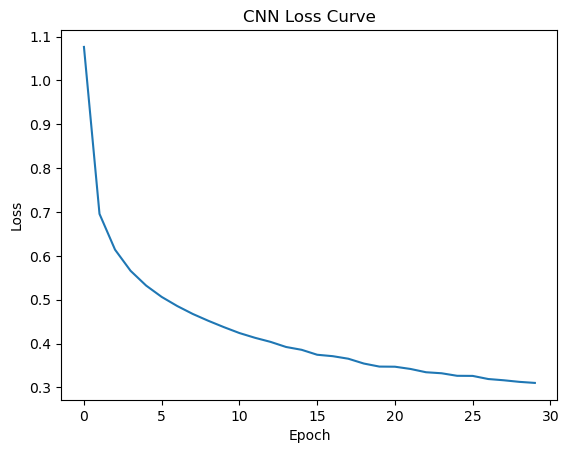

In [14]:
ctime, history = train_model(c, "CNN", X_train_cnn, y_train)
print(f"Training time for CNN: {ctime:.2f} seconds")

loss = c.history_["loss"]

plt.plot(loss)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Loss Curve")
plt.savefig('figures/CNN_loss_curve.png')
plt.show()

Logistic Regression Accuracy: 0.84  Precision: 0.8387990605560331  Recall: 0.84  F1 Score: 0.839053198567673


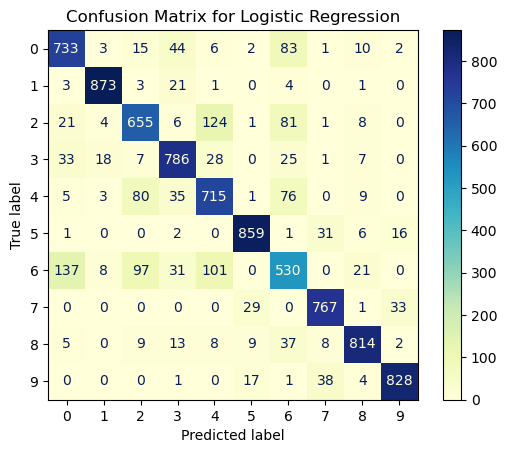

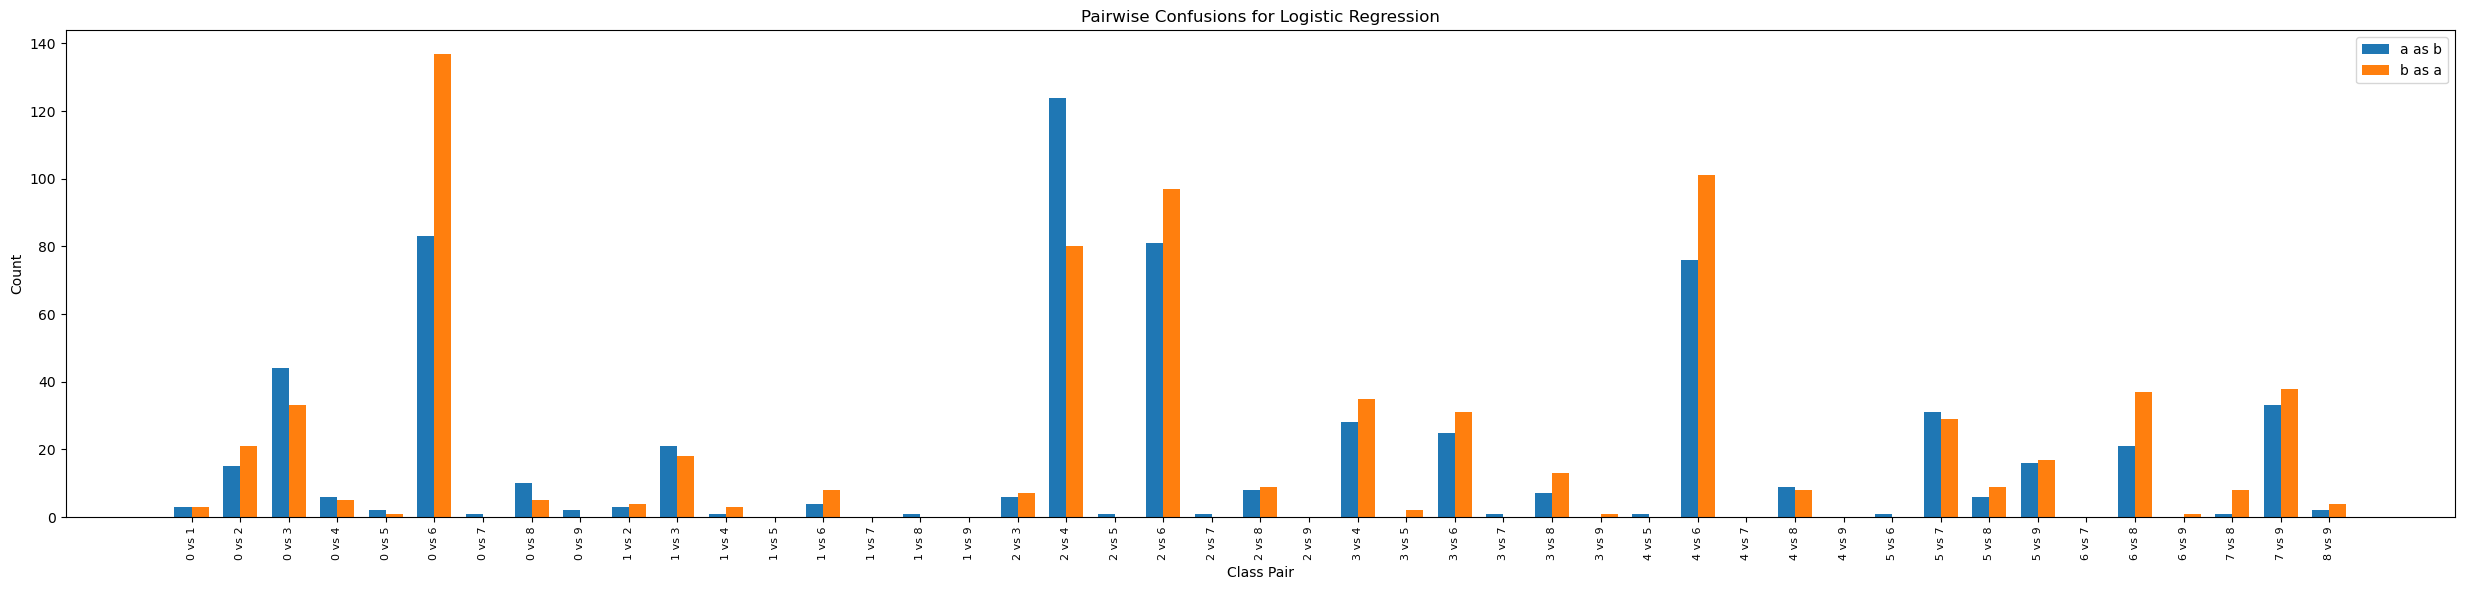

Logistic Regression class 0 AUC: 0.9793475008715742
Logistic Regression class 1 AUC: 0.9973997581398697
Logistic Regression class 2 AUC: 0.9703491709627216
Logistic Regression class 3 AUC: 0.9884577820699634
Logistic Regression class 4 AUC: 0.9733371713312278
Logistic Regression class 5 AUC: 0.9971013960402672
Logistic Regression class 6 AUC: 0.9329648062923606
Logistic Regression class 7 AUC: 0.9959779386825146
Logistic Regression class 8 AUC: 0.9895304038029068
Logistic Regression class 9 AUC: 0.9969222038590263


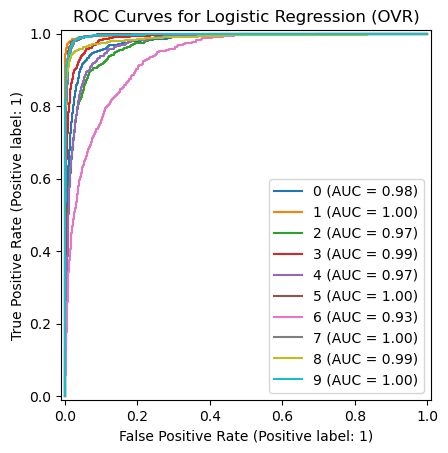

Logistic Regression pair 1 vs 5 AUC: 1.0
Logistic Regression pair 1 vs 7 AUC: 0.9999095720630867
Logistic Regression pair 1 vs 9 AUC: 0.9998721186341774


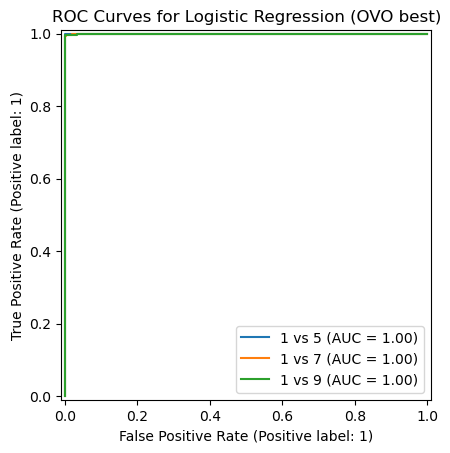

Logistic Regression pair 0 vs 6 AUC: 0.8334329435108078
Logistic Regression pair 2 vs 4 AUC: 0.897151313355531
Logistic Regression pair 2 vs 6 AUC: 0.8257803641599425
Logistic Regression pair 4 vs 6 AUC: 0.853056043056043
Logistic Regression pair 0 vs 3 AUC: 0.9705062100922449


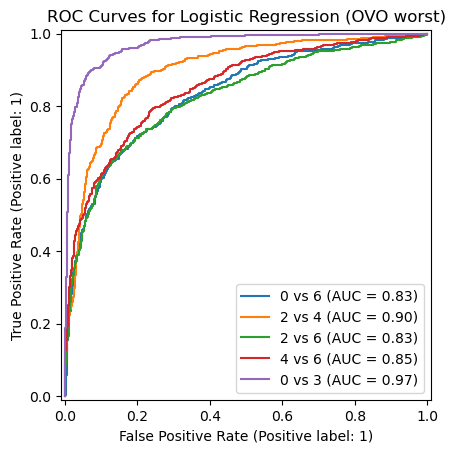

Validation time for Logistic Regression: 2.68 seconds


In [15]:
le, levals, letime = evaluate_model(l, "Logistic Regression", X_val, y_val, stage="validation", color="YlGnBu")
print(f"Validation time for Logistic Regression: {letime:.2f} seconds")

kNN Accuracy: 0.8502222222222222  Precision: 0.8532788767742758  Recall: 0.8502222222222222  F1 Score: 0.8499514169303215


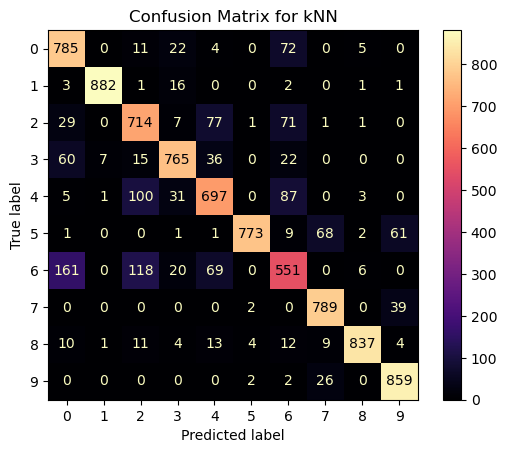

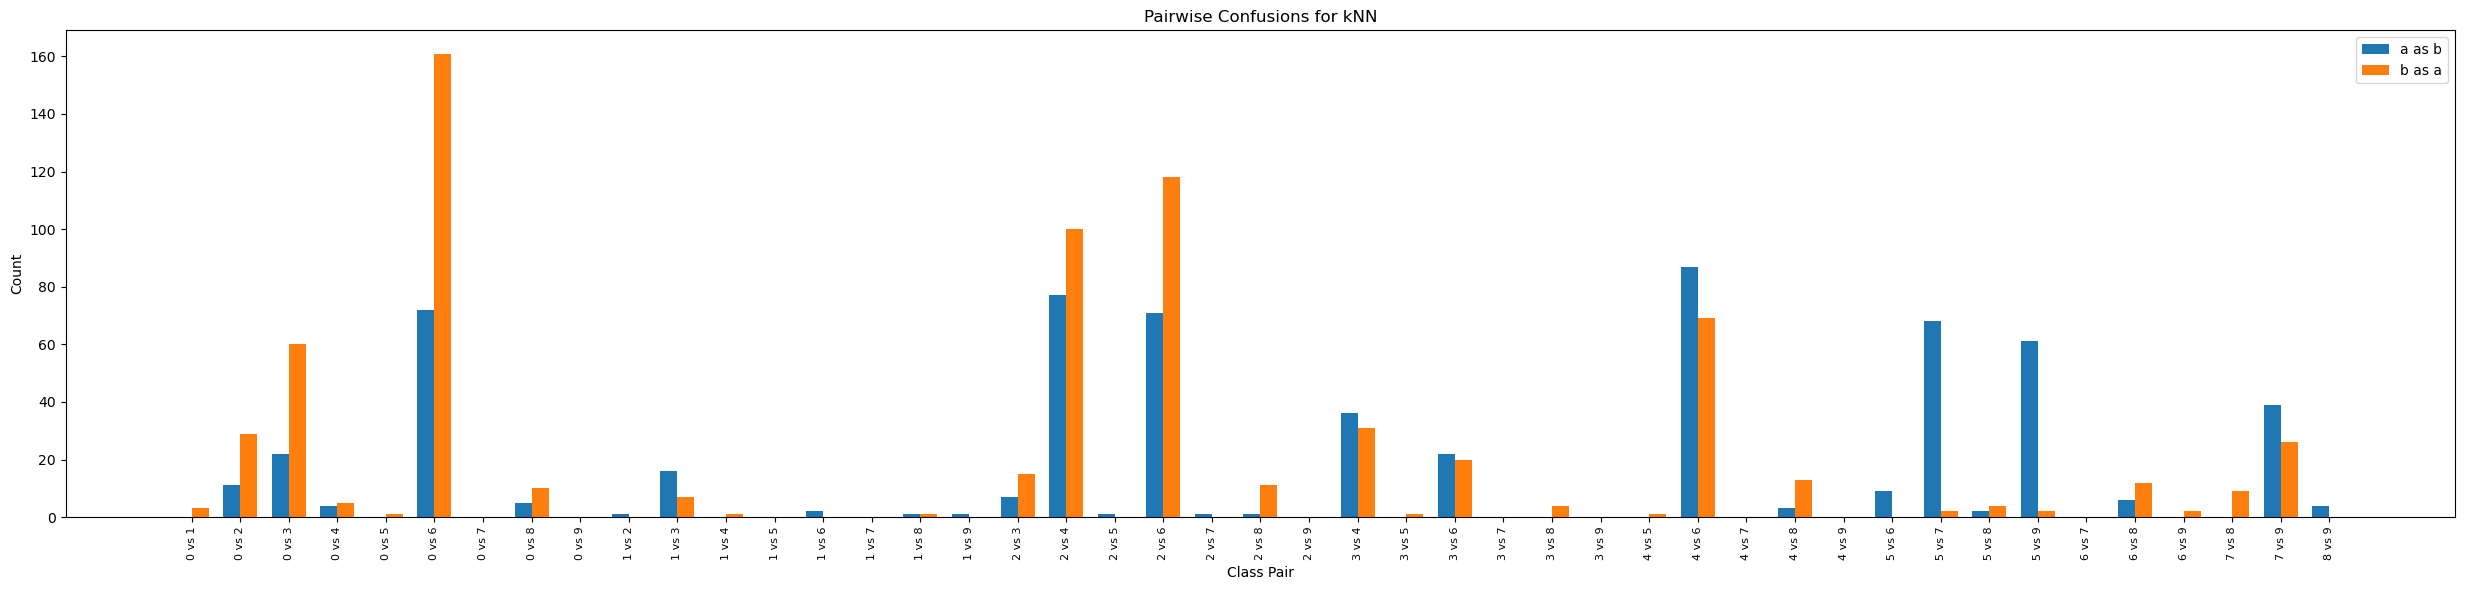

kNN class 0 AUC: 0.9594617399162053
kNN class 1 AUC: 0.9916313067592651
kNN class 2 AUC: 0.9318775601432825
kNN class 3 AUC: 0.9613418691709976
kNN class 4 AUC: 0.9333729461886965
kNN class 5 AUC: 0.9623190938378466
kNN class 6 AUC: 0.8643193707639527
kNN class 7 AUC: 0.9871057055639939
kNN class 8 AUC: 0.9789254672586242
kNN class 9 AUC: 0.9902099372333728


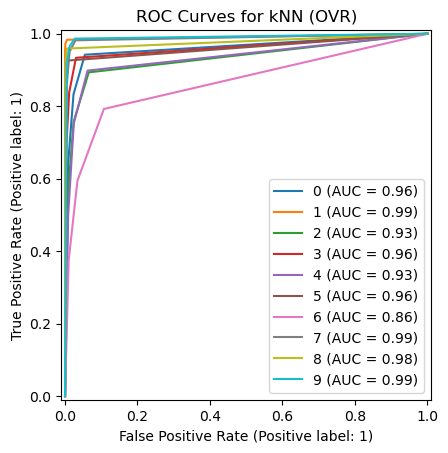

kNN pair 0 vs 7 AUC: 0.9909638554216867
kNN pair 0 vs 9 AUC: 0.9932508436445444
kNN pair 1 vs 5 AUC: 0.962882096069869


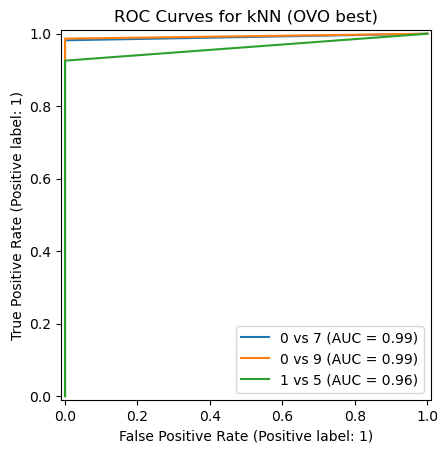

kNN pair 0 vs 6 AUC: 0.8178023629859001
kNN pair 2 vs 6 AUC: 0.8224081351051384
kNN pair 2 vs 4 AUC: 0.8918301454372486
kNN pair 4 vs 6 AUC: 0.8159868959868959
kNN pair 0 vs 3 AUC: 0.9549560899464722


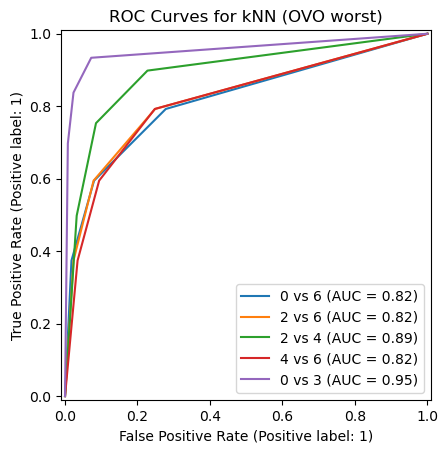

Validation time for kNN: 23.57 seconds


In [16]:
ke, kevals, k_eval_time = evaluate_model(k, "kNN", X_val, y_val, stage="validation", color="magma")
print(f"Validation time for kNN: {k_eval_time:.2f} seconds")

MLP Accuracy: 0.8842222222222222  Precision: 0.8845968302614832  Recall: 0.8842222222222222  F1 Score: 0.8834573459890405


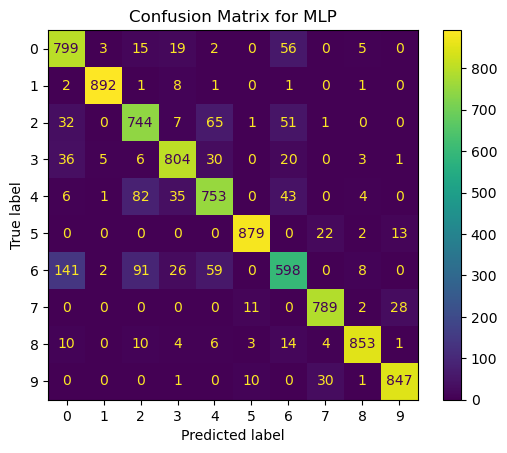

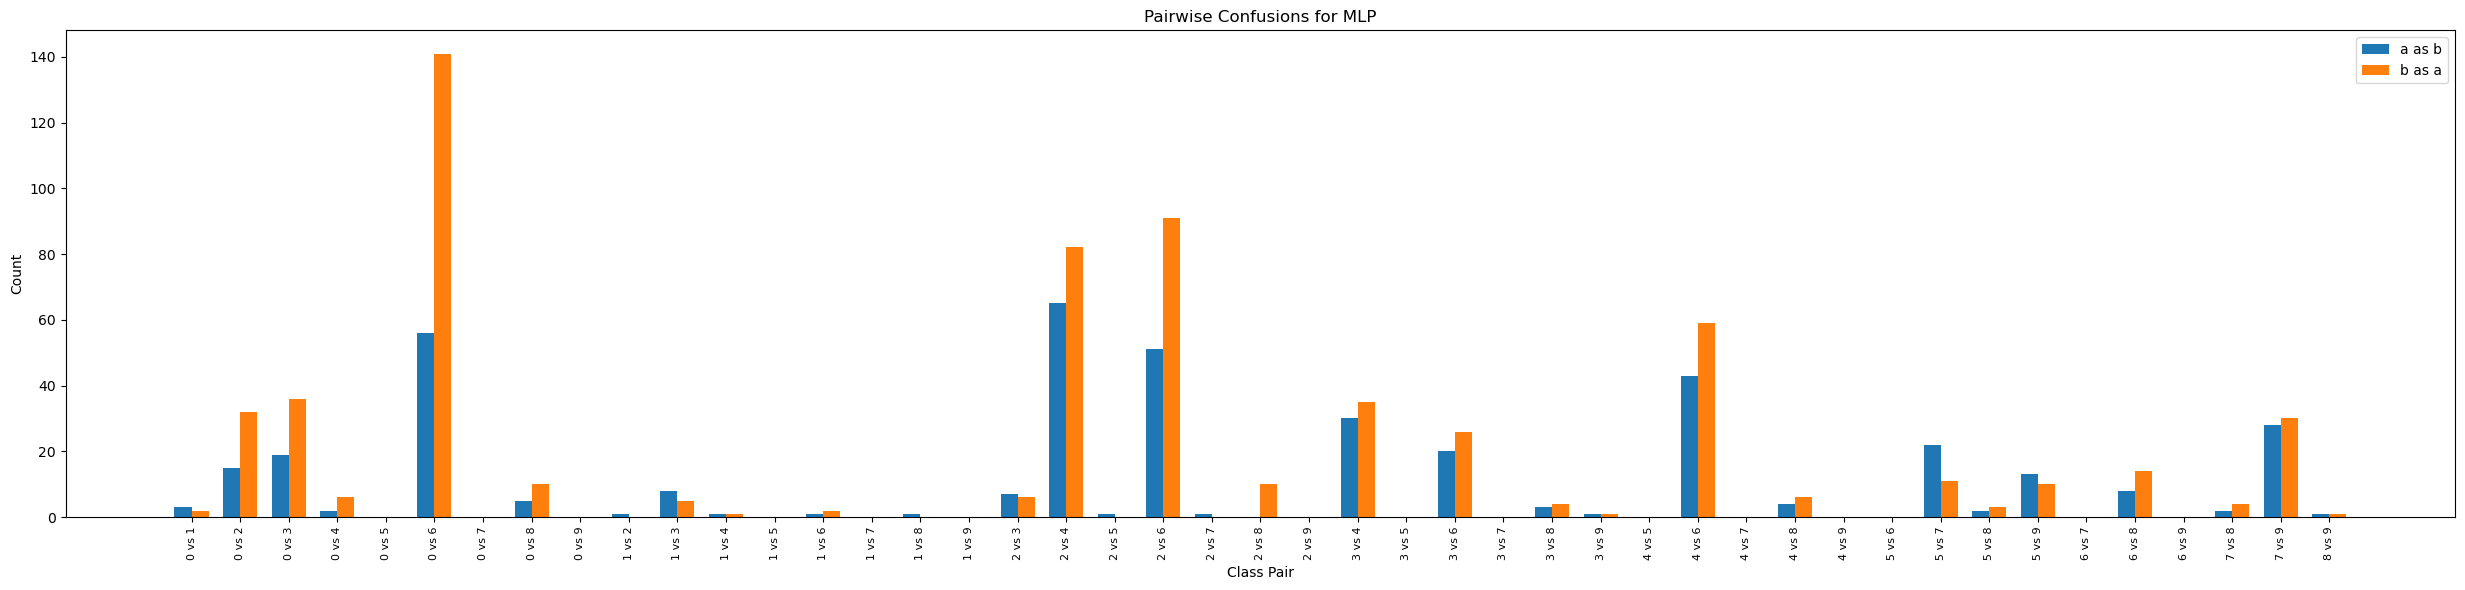

MLP class 0 AUC: 0.9891659099749972
MLP class 1 AUC: 0.9983153247356802
MLP class 2 AUC: 0.9810251851429569
MLP class 3 AUC: 0.9937109394995205
MLP class 4 AUC: 0.9848636277871047
MLP class 5 AUC: 0.9985505629752232
MLP class 6 AUC: 0.9652969625972722
MLP class 7 AUC: 0.9981870198050464
MLP class 8 AUC: 0.996783090305386
MLP class 9 AUC: 0.9979026247042755


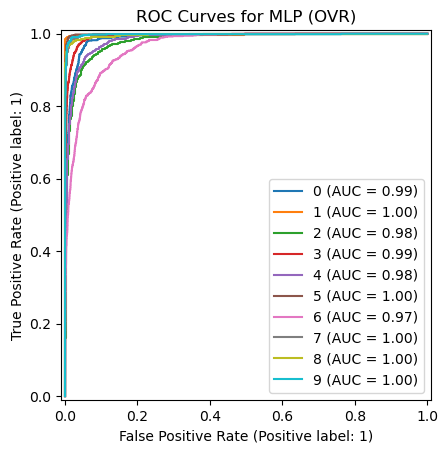

MLP pair 0 vs 5 AUC: 0.9992313147553566
MLP pair 0 vs 7 AUC: 0.9999061875980004
MLP pair 0 vs 9 AUC: 0.9990490621375331


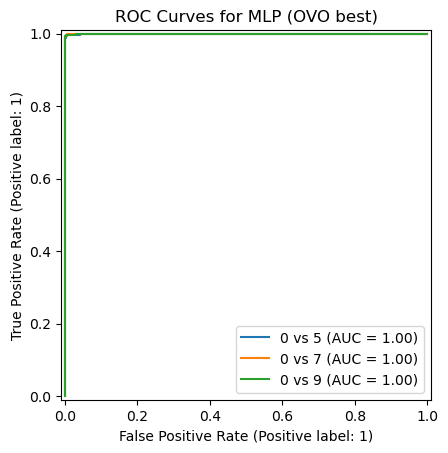

MLP pair 0 vs 6 AUC: 0.9188311336920904
MLP pair 2 vs 4 AUC: 0.9490933594707179
MLP pair 2 vs 6 AUC: 0.9146317905030448
MLP pair 4 vs 6 AUC: 0.9185269685269686
MLP pair 3 vs 4 AUC: 0.9770766066346177


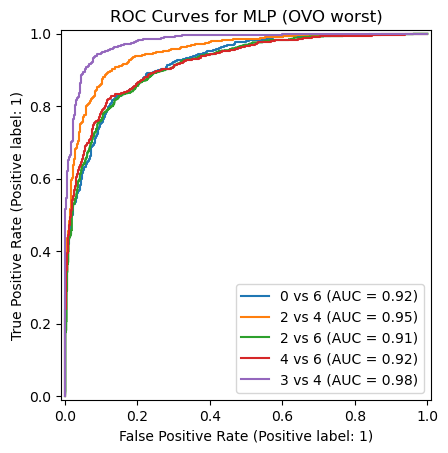

Validation time for MLP: 3.02 seconds


In [17]:
fe, fevals, fetime = evaluate_model(f, "MLP", X_val, y_val, stage="validation", color="viridis")
print(f"Validation time for MLP: {fetime:.2f} seconds")

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
CNN Accuracy: 0.8935555555555555  Precision: 0.8930135677409918  Recall: 0.8935555555555555  F1 Score: 0.892984370822313


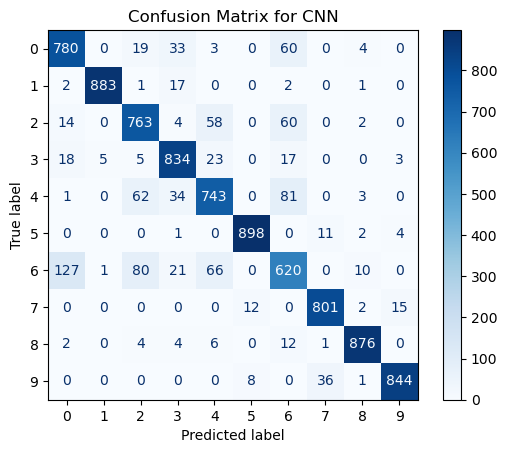

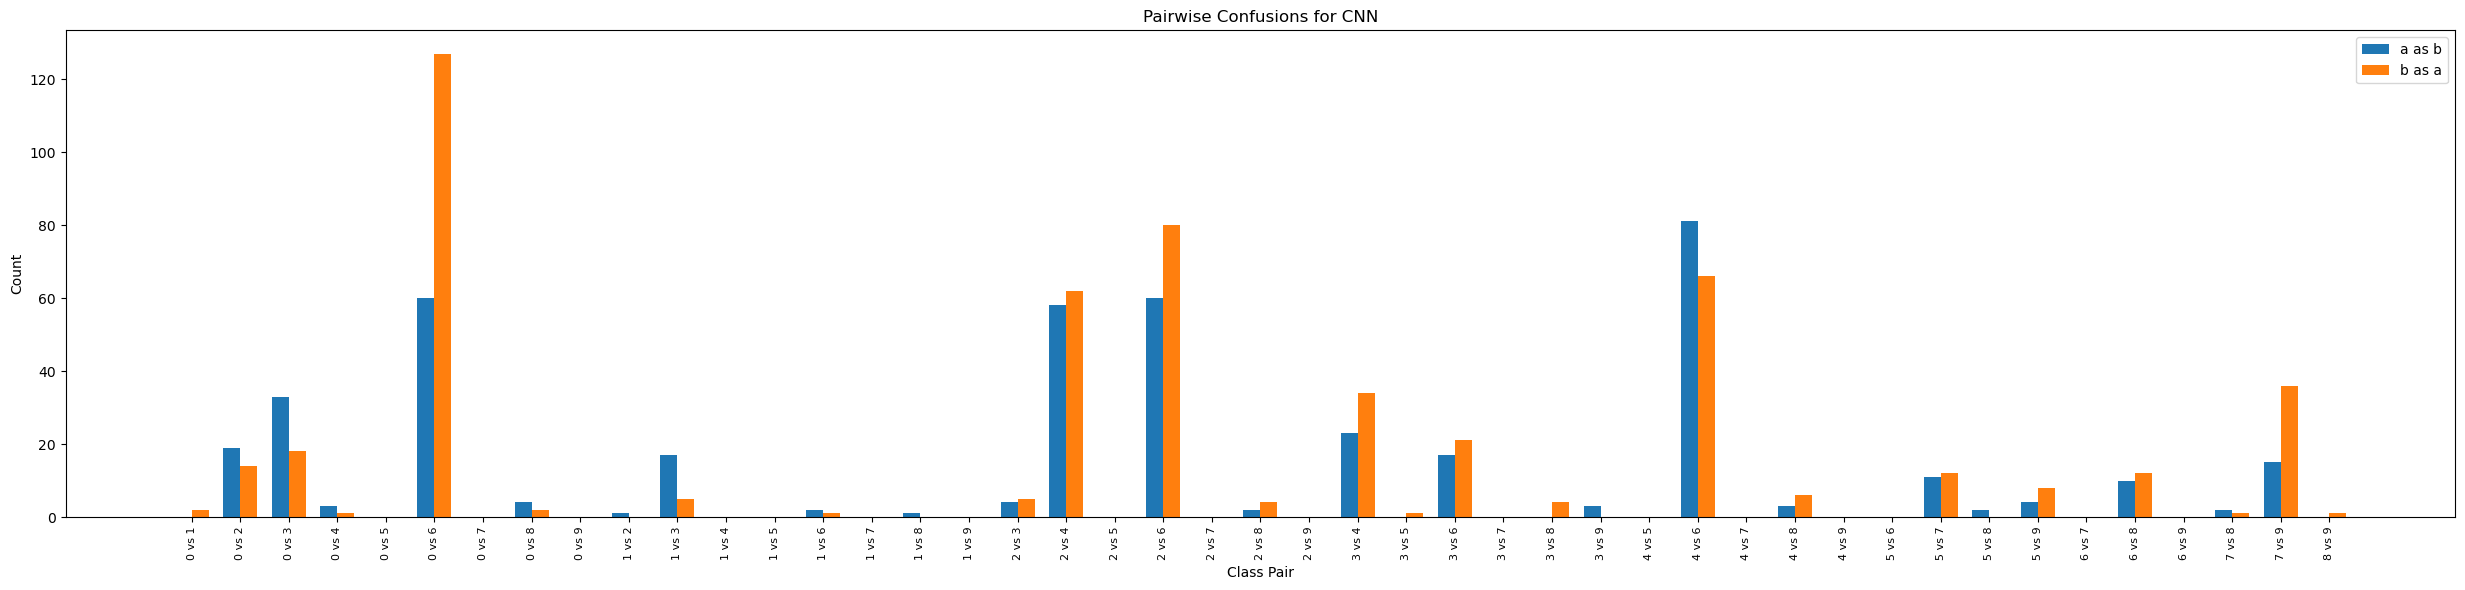

CNN class 0 AUC: 0.9896133341040994
CNN class 1 AUC: 0.9990339776936668
CNN class 2 AUC: 0.9866774909112387
CNN class 3 AUC: 0.9946016741798873
CNN class 4 AUC: 0.9846851287230188
CNN class 5 AUC: 0.9996187682175584
CNN class 6 AUC: 0.9649038908877918
CNN class 7 AUC: 0.9989742077244105
CNN class 8 AUC: 0.9992390091421279
CNN class 9 AUC: 0.9992721905939788


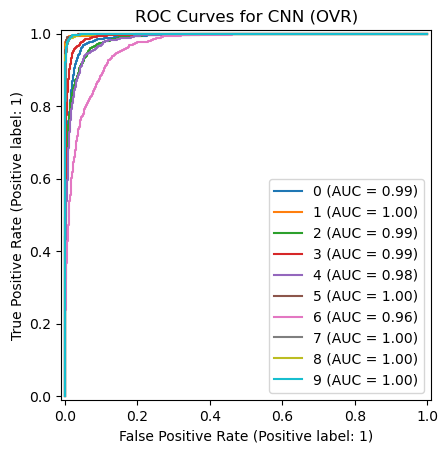

CNN pair 0 vs 5 AUC: 0.9999659981250394
CNN pair 0 vs 7 AUC: 1.0
CNN pair 0 vs 9 AUC: 0.9999949950638817


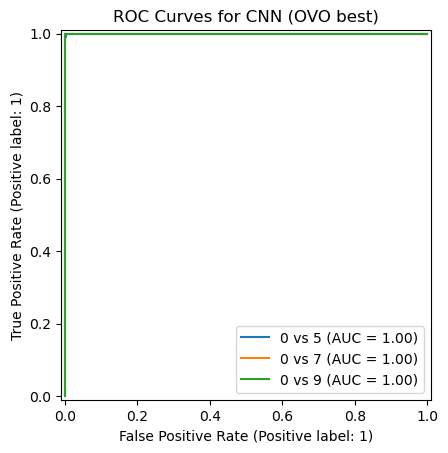

CNN pair 0 vs 6 AUC: 0.8969665995249977
CNN pair 4 vs 6 AUC: 0.9089212589212589
CNN pair 2 vs 6 AUC: 0.9227344992050874
CNN pair 2 vs 4 AUC: 0.9537526846072906
CNN pair 3 vs 4 AUC: 0.9773325201501997


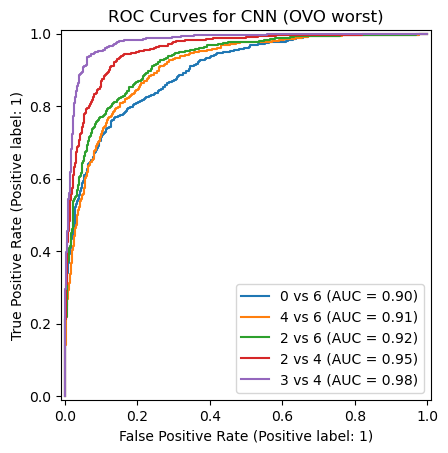

Validation time for CNN: 4.11 seconds


In [18]:
ce, cevals, ctime = evaluate_model(c, "CNN", X_val_cnn, y_val, stage="validation", color="Blues")
print(f"Validation time for CNN: {ctime:.2f} seconds")

Random Forest Accuracy: 0.8811111111111111  Precision: 0.8803659371337844  Recall: 0.8811111111111111  F1 Score: 0.8795212588749474


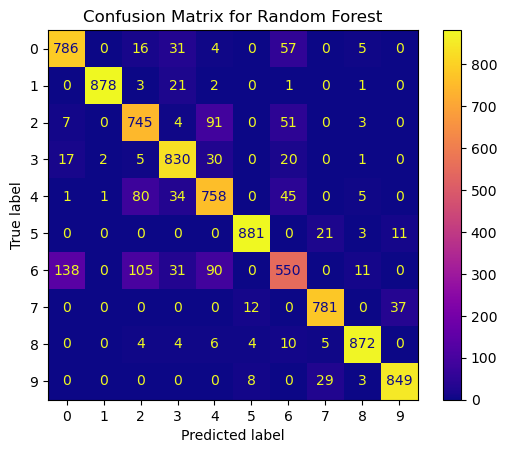

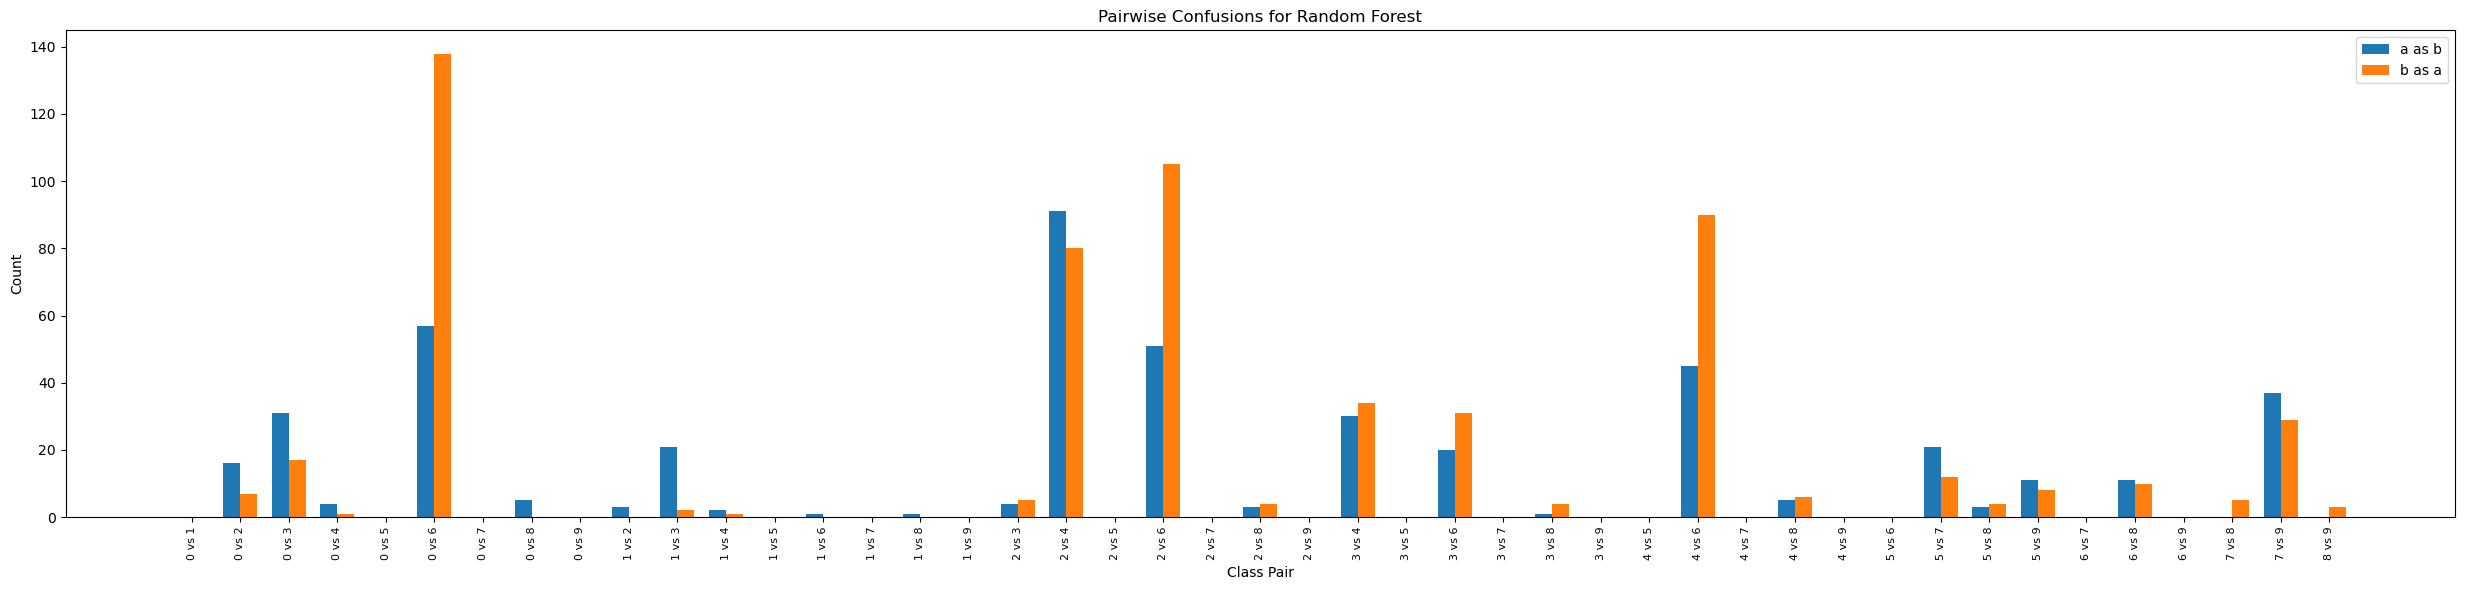

Random Forest class 0 AUC: 0.9900287650393758
Random Forest class 1 AUC: 0.998870951201964
Random Forest class 2 AUC: 0.9838917644975833
Random Forest class 3 AUC: 0.9946229000235463
Random Forest class 4 AUC: 0.9818971529131261
Random Forest class 5 AUC: 0.9994499620793891
Random Forest class 6 AUC: 0.9613964354447326
Random Forest class 7 AUC: 0.9981938033652358
Random Forest class 8 AUC: 0.9971723900231709
Random Forest class 9 AUC: 0.9987241146083469


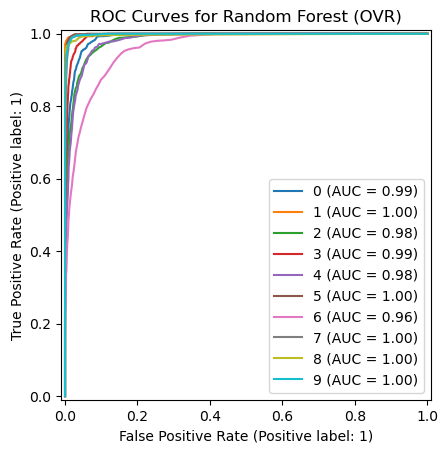

Random Forest pair 0 vs 1 AUC: 0.9988201263606606
Random Forest pair 0 vs 5 AUC: 0.9999829990625198
Random Forest pair 0 vs 7 AUC: 0.9999946392913144


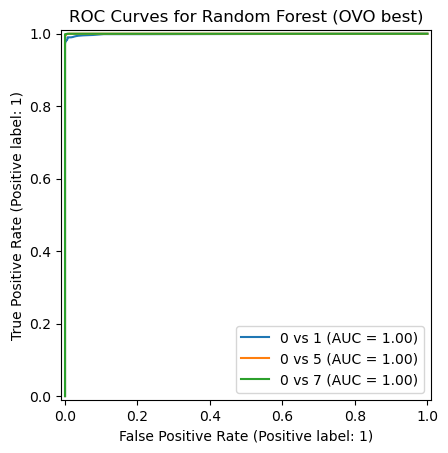

Random Forest pair 0 vs 6 AUC: 0.8777458437302708
Random Forest pair 2 vs 4 AUC: 0.9293990323402088
Random Forest pair 2 vs 6 AUC: 0.9047526772055073
Random Forest pair 4 vs 6 AUC: 0.9171539721539722
Random Forest pair 7 vs 9 AUC: 0.9907327849079106


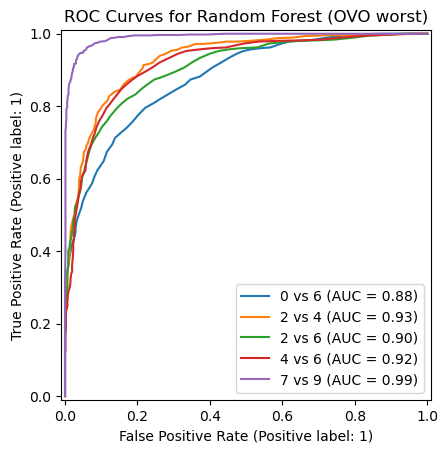

Validation time for Random Forest: 2.87 seconds


In [19]:
re, revals, retime = evaluate_model(r, "Random Forest", X_val, y_val, stage="validation", color="plasma")
print(f"Validation time for Random Forest: {retime:.2f} seconds")

# Final Testing and Evaluations

Logistic Regression Accuracy: 0.8326  Precision: 0.8309230661340458  Recall: 0.8326  F1 Score: 0.8315503705770807


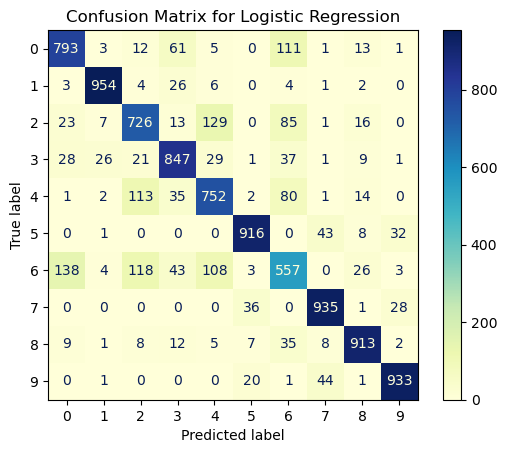

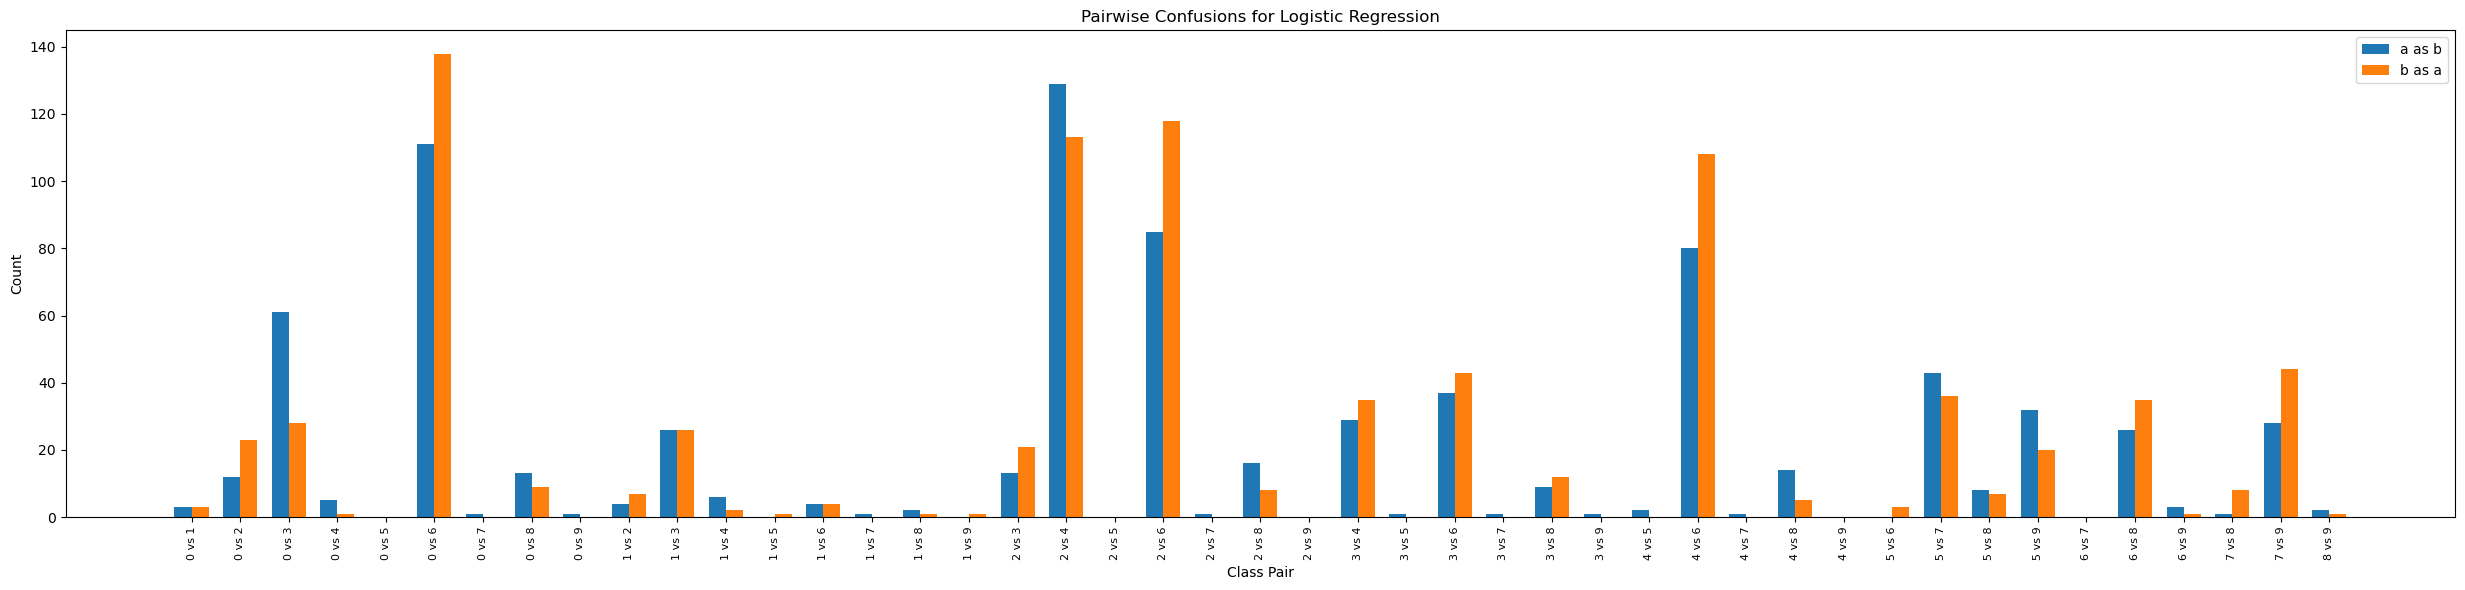

Logistic Regression class 0 AUC: 0.9783791111111112
Logistic Regression class 1 AUC: 0.9971729999999999
Logistic Regression class 2 AUC: 0.9680051111111111
Logistic Regression class 3 AUC: 0.9850402222222222
Logistic Regression class 4 AUC: 0.971523
Logistic Regression class 5 AUC: 0.9967850000000001
Logistic Regression class 6 AUC: 0.926815111111111
Logistic Regression class 7 AUC: 0.9965398888888889
Logistic Regression class 8 AUC: 0.989815
Logistic Regression class 9 AUC: 0.9976731111111111


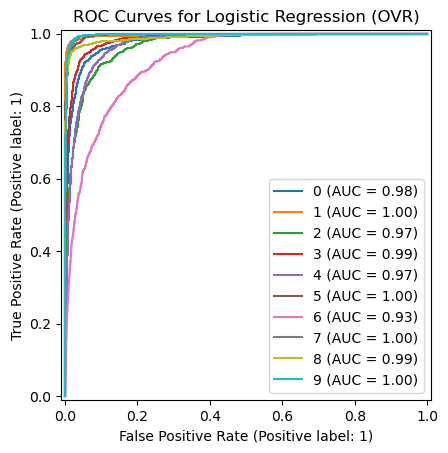

Logistic Regression pair 0 vs 5 AUC: 0.999682
Logistic Regression pair 2 vs 5 AUC: 0.9997929999999999
Logistic Regression pair 2 vs 9 AUC: 0.999948


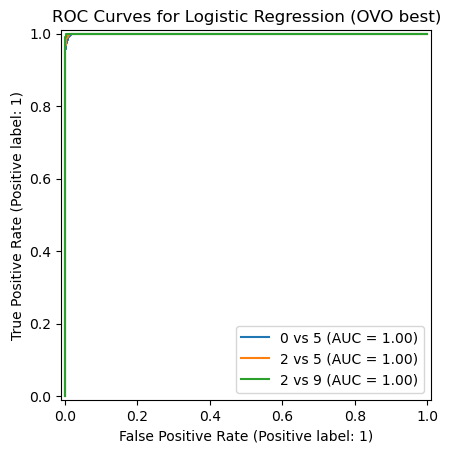

Logistic Regression pair 0 vs 6 AUC: 0.8117570000000001
Logistic Regression pair 2 vs 4 AUC: 0.8970449999999999
Logistic Regression pair 2 vs 6 AUC: 0.816046
Logistic Regression pair 4 vs 6 AUC: 0.8363700000000001
Logistic Regression pair 0 vs 3 AUC: 0.9635070000000001


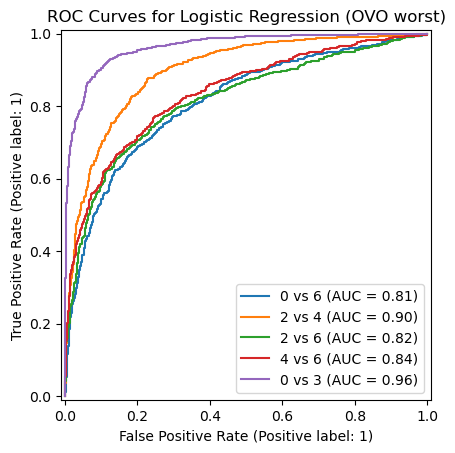

Test time for Logistic Regression: 2.75 seconds


In [20]:
le_test, le_test_vals, le_test_time = evaluate_model(l, "Logistic Regression", X_test, y_test, stage="test", color="YlGnBu")
print(f"Test time for Logistic Regression: {le_test_time:.2f} seconds")

kNN Accuracy: 0.848  Precision: 0.8511550621961887  Recall: 0.848  F1 Score: 0.8482031657959469


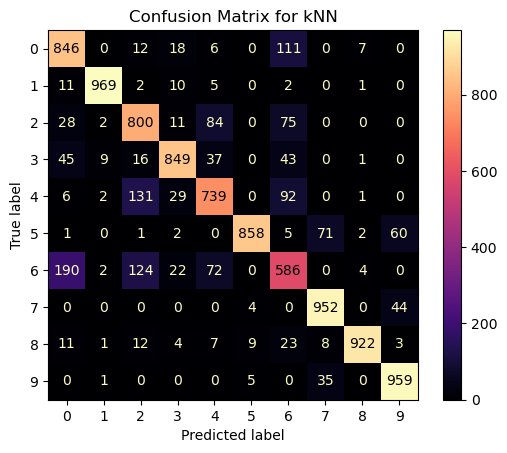

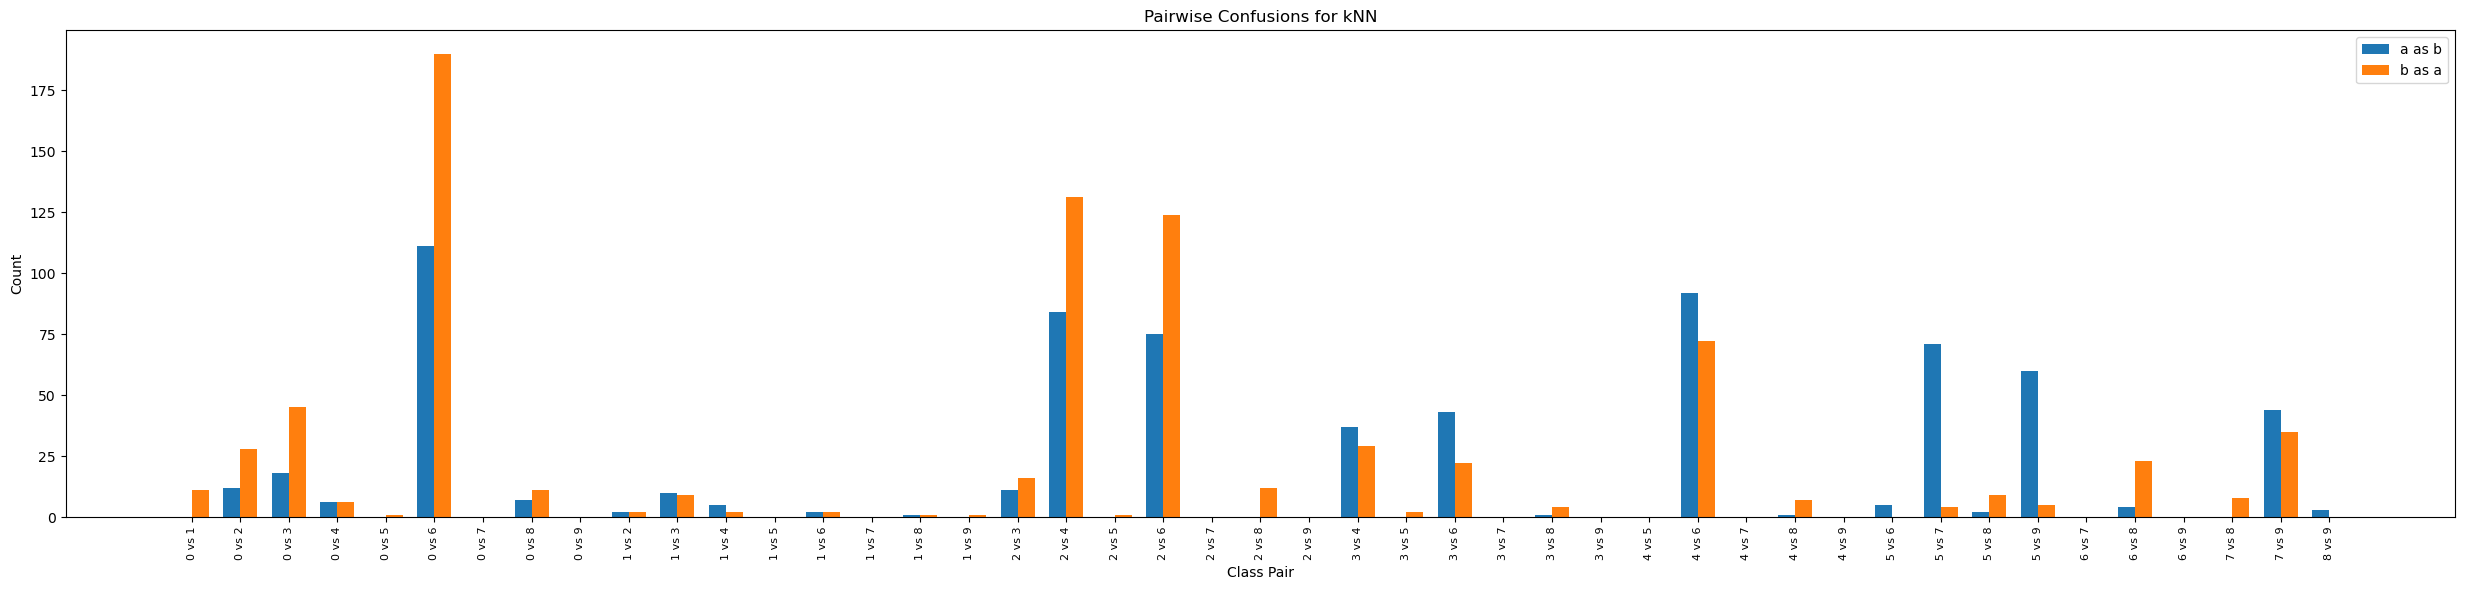

kNN class 0 AUC: 0.9530582222222223
kNN class 1 AUC: 0.9902855555555555
kNN class 2 AUC: 0.9374491111111111
kNN class 3 AUC: 0.961094
kNN class 4 AUC: 0.9318661111111112
kNN class 5 AUC: 0.9604700555555556
kNN class 6 AUC: 0.8668541666666667
kNN class 7 AUC: 0.9894713333333334
kNN class 8 AUC: 0.9774595555555555
kNN class 9 AUC: 0.9894232222222221


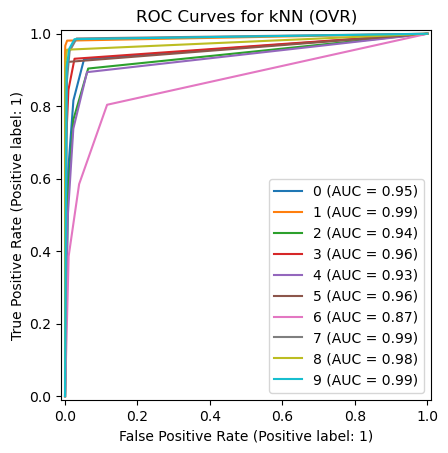

kNN pair 0 vs 7 AUC: 0.9934520000000001
kNN pair 0 vs 9 AUC: 0.9924999999999999
kNN pair 1 vs 5 AUC: 0.9610000000000001


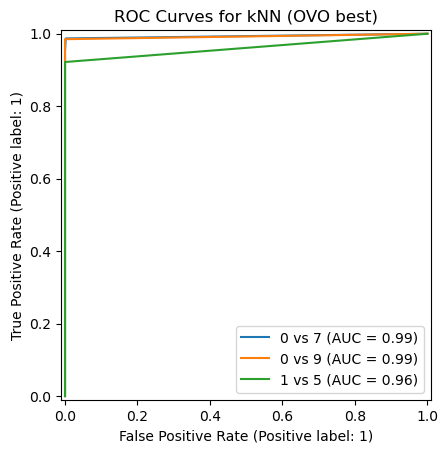

kNN pair 0 vs 6 AUC: 0.8060510000000001
kNN pair 2 vs 4 AUC: 0.890902
kNN pair 2 vs 6 AUC: 0.8292600000000001
kNN pair 4 vs 6 AUC: 0.8183395
kNN pair 7 vs 9 AUC: 0.9827135


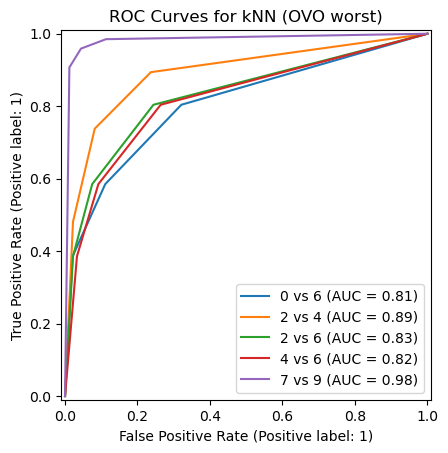

Test time for kNN: 413.22 seconds


In [21]:
ke_test, ke_test_vals, ke_test_time = evaluate_model(k, "kNN", X_test, y_test, stage="test", color="magma")
print(f"Test time for kNN: {ke_test_time:.2f} seconds")

MLP Accuracy: 0.8857  Precision: 0.8852973982654662  Recall: 0.8857  F1 Score: 0.8849525520340903


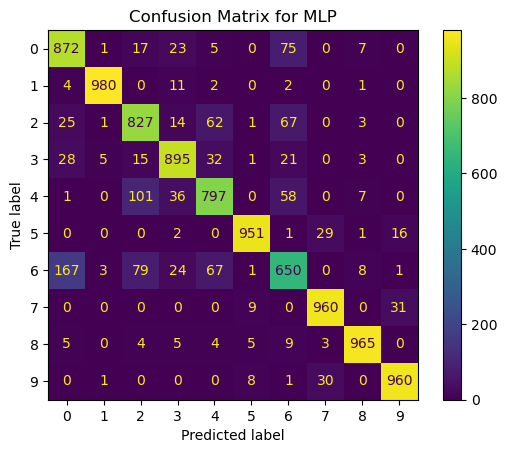

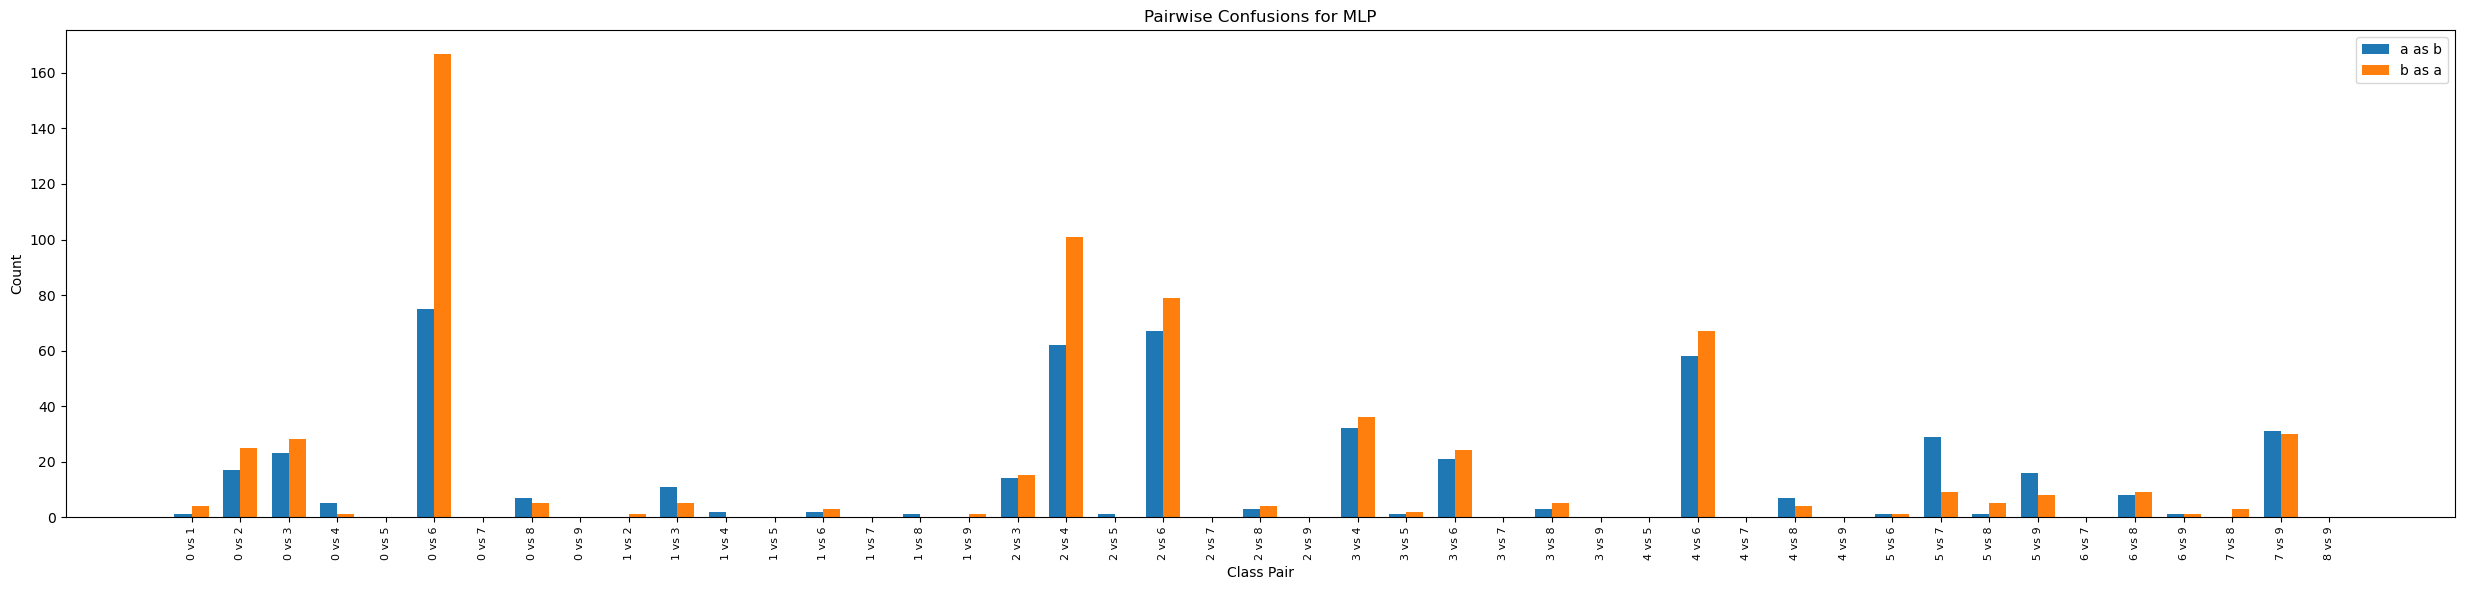

MLP class 0 AUC: 0.9852743333333335
MLP class 1 AUC: 0.9987277777777779
MLP class 2 AUC: 0.9775737222222223
MLP class 3 AUC: 0.9925673888888888
MLP class 4 AUC: 0.9818373333333333
MLP class 5 AUC: 0.9991041111111111
MLP class 6 AUC: 0.9574255555555555
MLP class 7 AUC: 0.9985048333333333
MLP class 8 AUC: 0.9965669444444445
MLP class 9 AUC: 0.9983914444444445


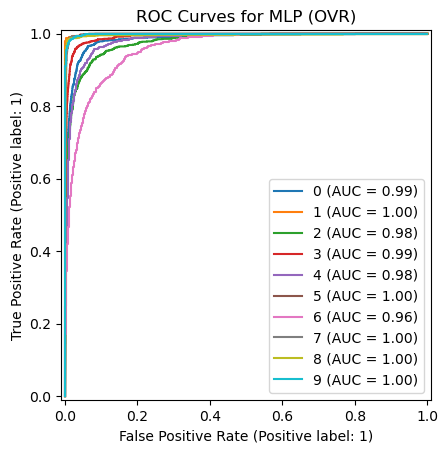

MLP pair 0 vs 5 AUC: 0.9998159999999999
MLP pair 0 vs 7 AUC: 0.9999399999999999
MLP pair 0 vs 9 AUC: 0.999476


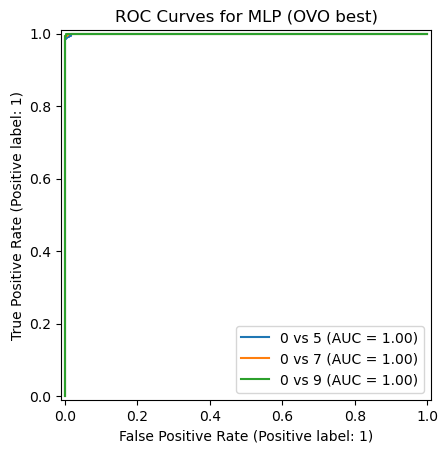

MLP pair 0 vs 6 AUC: 0.894058
MLP pair 2 vs 4 AUC: 0.94176
MLP pair 2 vs 6 AUC: 0.896682
MLP pair 4 vs 6 AUC: 0.899357
MLP pair 3 vs 4 AUC: 0.972024


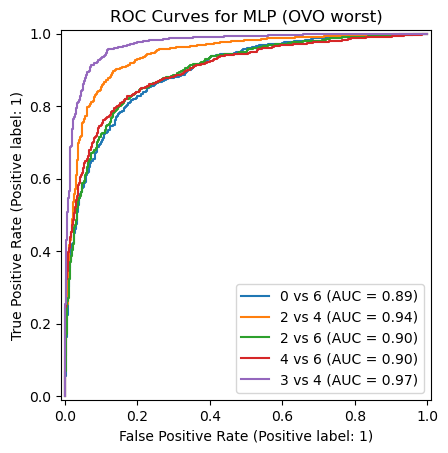

Test time for MLP: 4.27 seconds


In [22]:
fe_test, fe_test_vals, fe_test_time = evaluate_model(f, "MLP", X_test, y_test, stage="test", color="viridis")
print(f"Test time for MLP: {fe_test_time:.2f} seconds")

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
CNN Accuracy: 0.8866  Precision: 0.8861142123046051  Recall: 0.8866  F1 Score: 0.8862077697942504


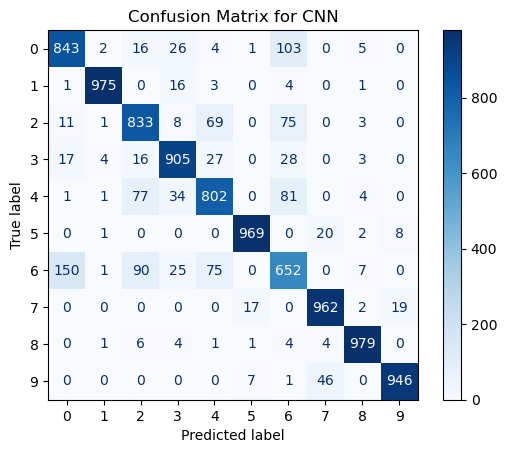

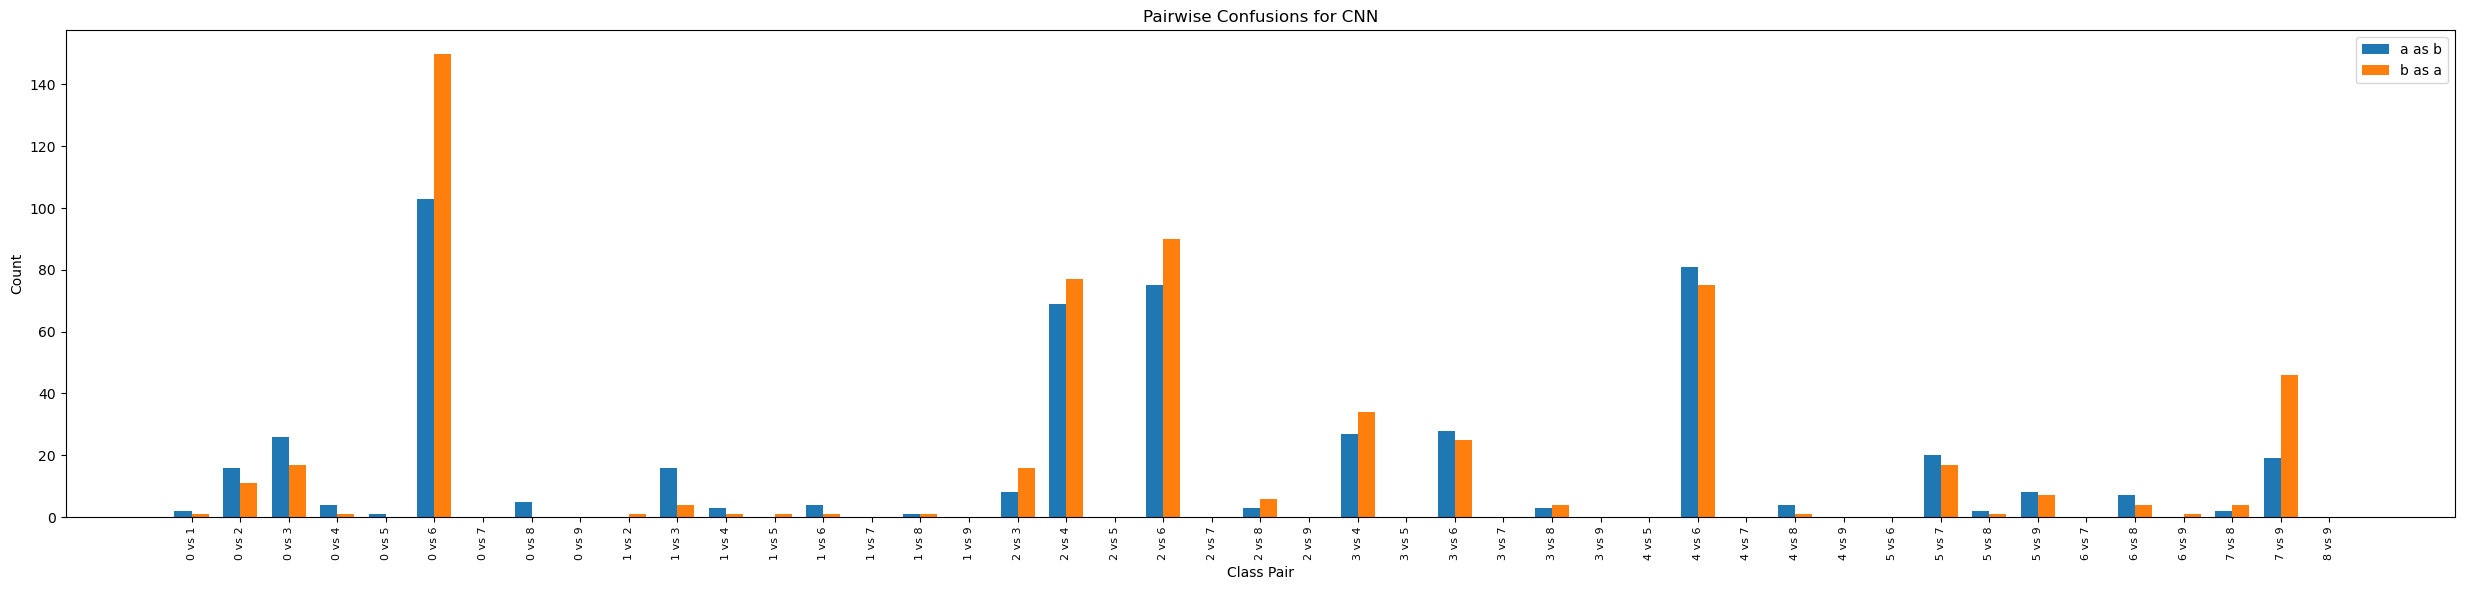

CNN class 0 AUC: 0.9883792777777779
CNN class 1 AUC: 0.9990823333333333
CNN class 2 AUC: 0.9836215555555554
CNN class 3 AUC: 0.9944955555555556
CNN class 4 AUC: 0.9838513333333334
CNN class 5 AUC: 0.9996114444444445
CNN class 6 AUC: 0.9582368888888888
CNN class 7 AUC: 0.9987452222222222
CNN class 8 AUC: 0.9990076666666665
CNN class 9 AUC: 0.9988544444444445


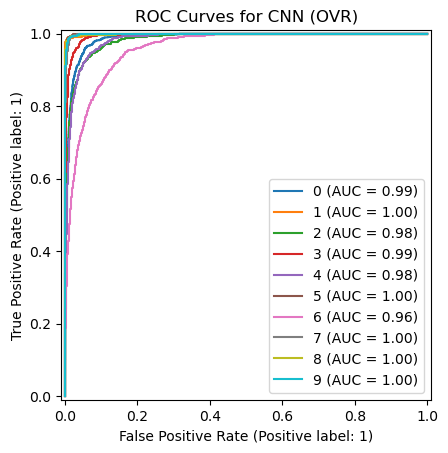

CNN pair 0 vs 7 AUC: 0.999996
CNN pair 0 vs 9 AUC: 0.999758
CNN pair 1 vs 7 AUC: 0.999999


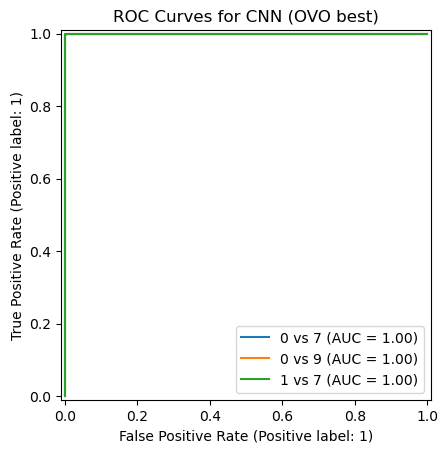

CNN pair 0 vs 6 AUC: 0.873261
CNN pair 2 vs 6 AUC: 0.907917
CNN pair 4 vs 6 AUC: 0.893045
CNN pair 2 vs 4 AUC: 0.94695
CNN pair 7 vs 9 AUC: 0.9942289999999999


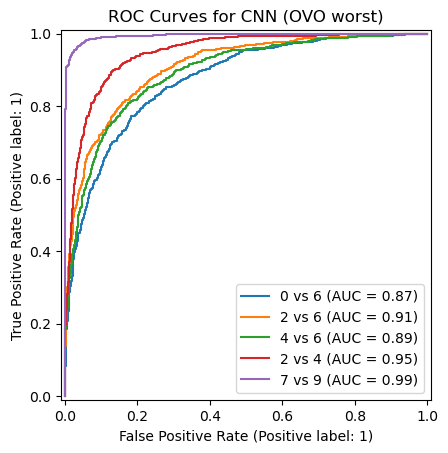

Test time for CNN: 4.69 seconds


In [23]:
ce_test, ce_test_vals, ce_test_time = evaluate_model(c, "CNN", X_test_cnn, y_test, stage="test", color="Blues")
print(f"Test time for CNN: {ce_test_time:.2f} seconds")

Random Forest Accuracy: 0.8745  Precision: 0.8735597747945514  Recall: 0.8745  F1 Score: 0.8730501086913438


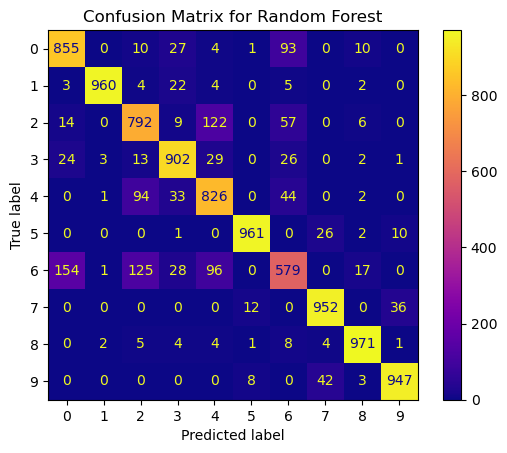

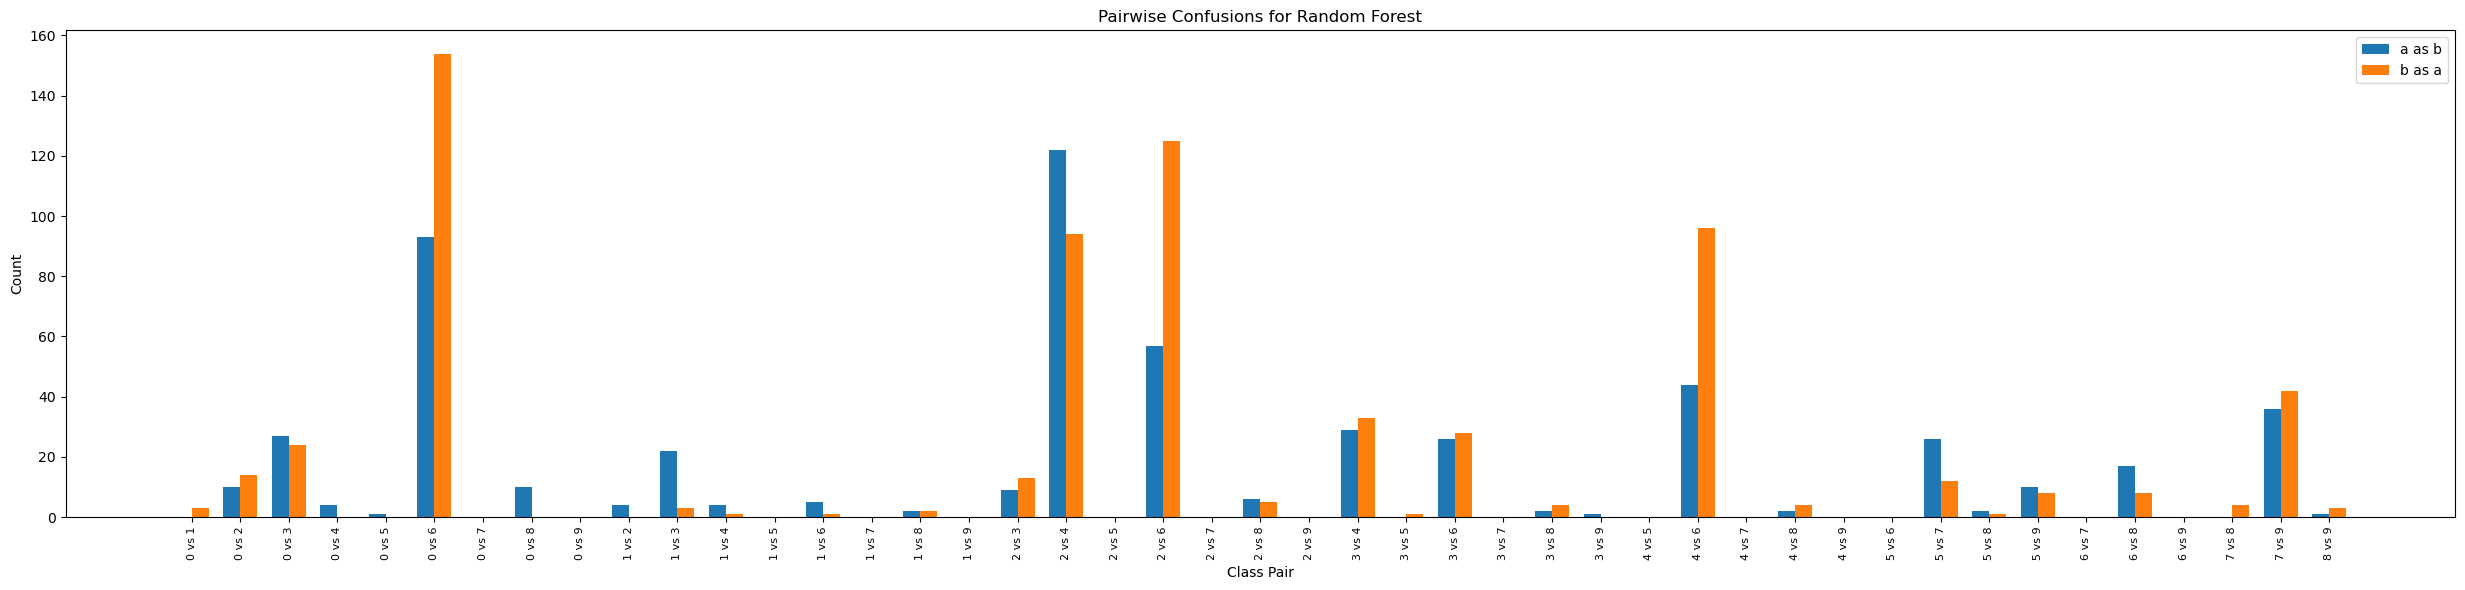

Random Forest class 0 AUC: 0.9870852777777778
Random Forest class 1 AUC: 0.9986050555555556
Random Forest class 2 AUC: 0.9803160555555557
Random Forest class 3 AUC: 0.9933369999999999
Random Forest class 4 AUC: 0.9830485555555555
Random Forest class 5 AUC: 0.9992593888888889
Random Forest class 6 AUC: 0.9556188888888889
Random Forest class 7 AUC: 0.9981622777777779
Random Forest class 8 AUC: 0.9975573888888889
Random Forest class 9 AUC: 0.998534


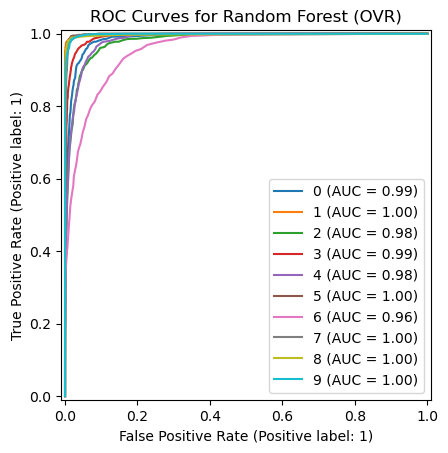

Random Forest pair 0 vs 7 AUC: 0.9999945
Random Forest pair 0 vs 9 AUC: 0.999959
Random Forest pair 1 vs 5 AUC: 0.9999945


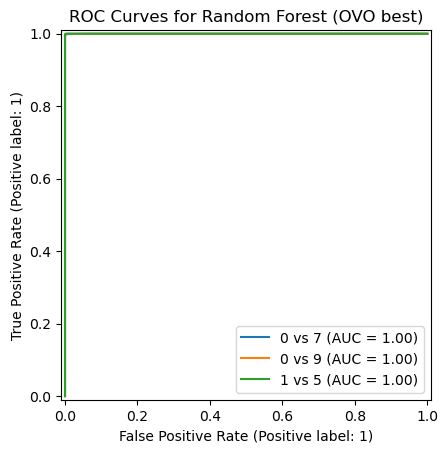

Random Forest pair 0 vs 6 AUC: 0.8525950000000001
Random Forest pair 2 vs 4 AUC: 0.9276565
Random Forest pair 2 vs 6 AUC: 0.894685
Random Forest pair 4 vs 6 AUC: 0.9113480000000002
Random Forest pair 7 vs 9 AUC: 0.9910135000000001


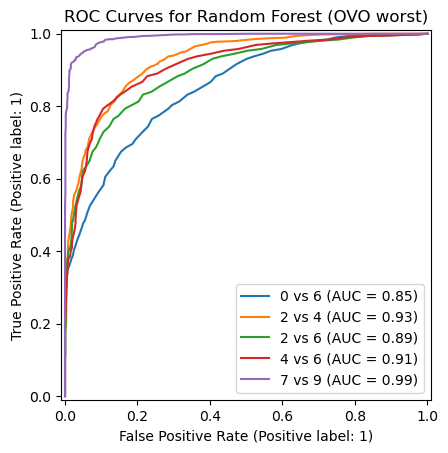

Test time for Random Forest: 2.64 seconds


In [24]:
re_test, re_test_vals, re_test_time = evaluate_model(r, "Random Forest", X_test, y_test, stage="test", color="plasma")
print(f"Test time for Random Forest: {re_test_time:.2f} seconds")

# Comparing All Models

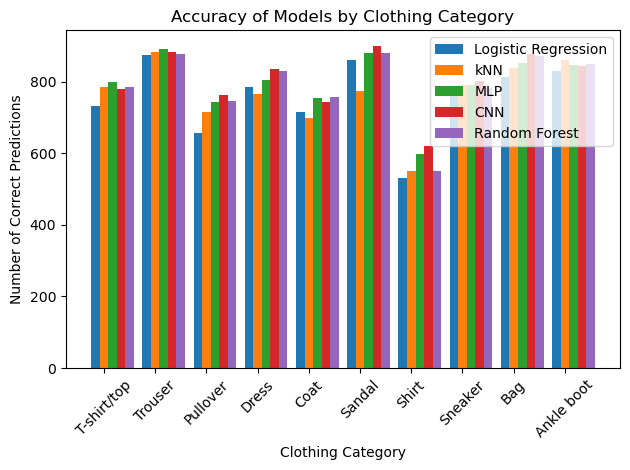

In [29]:
models = ["Logistic Regression", "kNN", "MLP", "CNN", "Random Forest"]
catcounts = {"Logistic Regression": np.diag(levals.cm) , "kNN": np.diag(kevals.cm) , "MLP": np.diag(fevals.cm), "CNN": np.diag(cevals.cm), "Random Forest": np.diag(revals.cm)}
cataccs = {model: counts/(len(y_test)/len(clothing_types)) for model, counts in catcounts.items()}

# Graph the numeric accuracies
x = np.arange(len(clothing_types))
width = 1/(len(models) + 1)
[plt.bar(x - width + i*width, catcounts[model], width, label=model) for i, model in enumerate(models)]
plt.xlabel('Clothing Category')
plt.ylabel('Number of Correct Predictions')
plt.title('Accuracy of Models by Clothing Category')
plt.xticks(x, [clothing_types[i] for i in clothing_types.keys()], rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('figures/model_category_accuracies.png')
plt.show()

In [30]:
[print(f"{model} Category Accuracy: {cataccs[model]}") for model in models]
totaccs = {model: np.round(np.mean(cataccs[model]), 4) for model in models}
print("Sorted by Overall Accuracy:", sorted([{"Logistic Regression": totaccs["Logistic Regression"]}, {"kNN": totaccs["kNN"]}, {"MLP": totaccs["MLP"]}, {"CNN": totaccs["CNN"]} , {"Random Forest": totaccs["Random Forest"]}], key=lambda x: list(x.values())[0], reverse=True))

Logistic Regression Category Accuracy: [0.733 0.873 0.655 0.786 0.715 0.859 0.53  0.767 0.814 0.828]
kNN Category Accuracy: [0.785 0.882 0.714 0.765 0.697 0.773 0.551 0.789 0.837 0.859]
MLP Category Accuracy: [0.799 0.892 0.744 0.804 0.753 0.879 0.598 0.789 0.853 0.847]
CNN Category Accuracy: [0.78  0.883 0.763 0.834 0.743 0.898 0.62  0.801 0.876 0.844]
Random Forest Category Accuracy: [0.786 0.878 0.745 0.83  0.758 0.881 0.55  0.781 0.872 0.849]
Sorted by Overall Accuracy: [{'CNN': np.float64(0.8042)}, {'MLP': np.float64(0.7958)}, {'Random Forest': np.float64(0.793)}, {'kNN': np.float64(0.7652)}, {'Logistic Regression': np.float64(0.756)}]


In [31]:
performance_by_category = pd.DataFrame({model: cataccs[model] for model in models}, index=[clothing_types[i] for i in clothing_types.keys()])
print("Performance by Category:", performance_by_category, sep="\n")
print("\nSorted by Category Accuracy:")
for category in performance_by_category.index:
    sorted_models = performance_by_category.loc[category].sort_values(ascending=False)
    print(f"Category {category}: {sorted_models.to_dict()}")

Performance by Category:
             Logistic Regression    kNN    MLP    CNN  Random Forest
T-shirt/top                0.733  0.785  0.799  0.780          0.786
Trouser                    0.873  0.882  0.892  0.883          0.878
Pullover                   0.655  0.714  0.744  0.763          0.745
Dress                      0.786  0.765  0.804  0.834          0.830
Coat                       0.715  0.697  0.753  0.743          0.758
Sandal                     0.859  0.773  0.879  0.898          0.881
Shirt                      0.530  0.551  0.598  0.620          0.550
Sneaker                    0.767  0.789  0.789  0.801          0.781
Bag                        0.814  0.837  0.853  0.876          0.872
Ankle boot                 0.828  0.859  0.847  0.844          0.849

Sorted by Category Accuracy:
Category T-shirt/top: {'MLP': 0.799, 'Random Forest': 0.786, 'kNN': 0.785, 'CNN': 0.78, 'Logistic Regression': 0.733}
Category Trouser: {'MLP': 0.892, 'CNN': 0.883, 'kNN': 0.882, 'Random

In [32]:
best_model_by_category = performance_by_category.idxmax(axis=1)
print(f"Best model by category:", best_model_by_category, sep="\n")
print(f"Model best performace counts by category: \n{best_model_by_category.value_counts()}")
print(f"Model with most category wins: {best_model_by_category.value_counts().idxmax()}")

Best model by category:
T-shirt/top              MLP
Trouser                  MLP
Pullover                 CNN
Dress                    CNN
Coat           Random Forest
Sandal                   CNN
Shirt                    CNN
Sneaker                  CNN
Bag                      CNN
Ankle boot               kNN
dtype: object
Model best performace counts by category: 
CNN              6
MLP              2
Random Forest    1
kNN              1
Name: count, dtype: int64
Model with most category wins: CNN
